Likith N A

In [6]:
import pandas as pd

df = pd.read_csv('dirty_data.csv')
print(df.head())
df.info()


   Gender   Age  Married  Employed  Two_Four_Wheeler  Cinema_Likes     Money
0     1.0  55.0      1.0       2.0               0.0             2  935816.0
1     NaN  24.0      0.0       2.0               0.0             1  593336.0
2     2.0  24.0      0.0       2.0               0.0             2  827144.0
3     1.0  22.0      0.0       2.0               0.0             2  515073.0
4     1.0  25.0      1.0       2.0               1.0             2  541315.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            1183 non-null   float64
 1   Age               1190 non-null   float64
 2   Married           1190 non-null   float64
 3   Employed          1175 non-null   float64
 4   Two_Four_Wheeler  1176 non-null   float64
 5   Cinema_Likes      1202 non-null   int64  
 6   Money             1172 non-null   float64
dtypes: f

In [12]:
for col in df.columns:
    unique_values = df[col].dropna().unique()
    if set(unique_values).issubset({0.0, 1.0}):
        df[col] = df[col].astype('object')

print("DataFrame after converting 0/1 coded columns to object type:")
print(df.info())

DataFrame after converting 0/1 coded columns to object type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            1183 non-null   float64
 1   Age               1190 non-null   float64
 2   Married           1190 non-null   object 
 3   Employed          1175 non-null   float64
 4   Two_Four_Wheeler  1176 non-null   object 
 5   Cinema_Likes      1202 non-null   int64  
 6   Money             1172 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 65.9+ KB
None


--- Continuous columns identified for imputation: ['Age', 'Money'] ---

Missing values before imputation:
Age      12
Money    30
dtype: int64
--------------------------------------------------

Missing values after Mean Imputation:
Age      0
Money    0
dtype: int64
--------------------------------------------------

Missing values after Median Imputation:
Age      0
Money    0
dtype: int64
--------------------------------------------------

Missing values after Forward Fill Imputation:
Age      0
Money    0
dtype: int64
--------------------------------------------------

Missing values after Backward Fill Imputation:
Age      0
Money    0
dtype: int64
--------------------------------------------------

Missing values after KNN Imputation:
Age      0
Money    0
dtype: int64
--------------------------------------------------

--- Performing Analysis on Mean-Imputed Data ---

Univariate Analysis (Descriptive Statistics for continuous variables):
               Age         Money
count  1

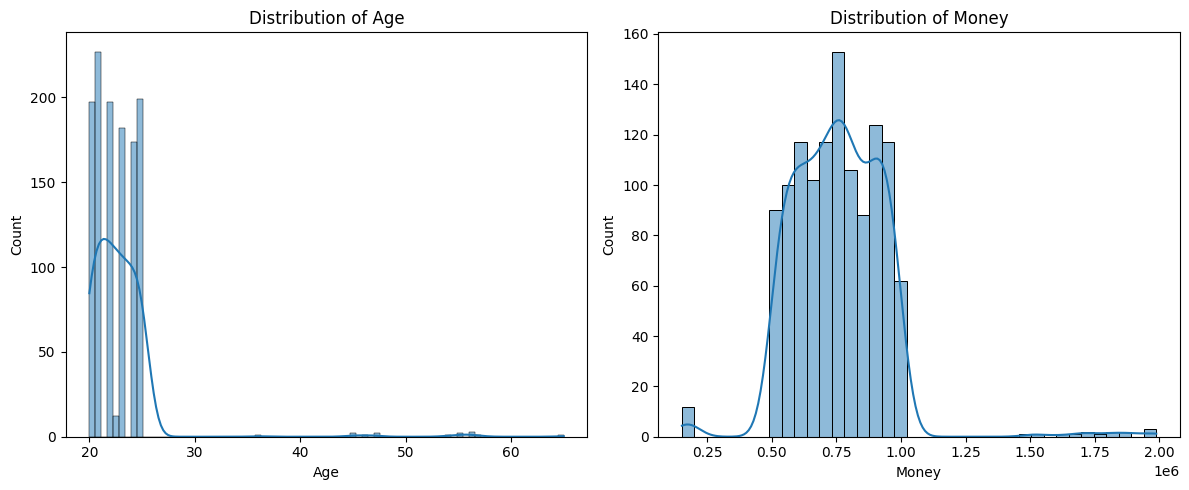


Bivariate Analysis (Correlation Matrix for continuous variables):
            Age     Money
Age    1.000000 -0.037945
Money -0.037945  1.000000


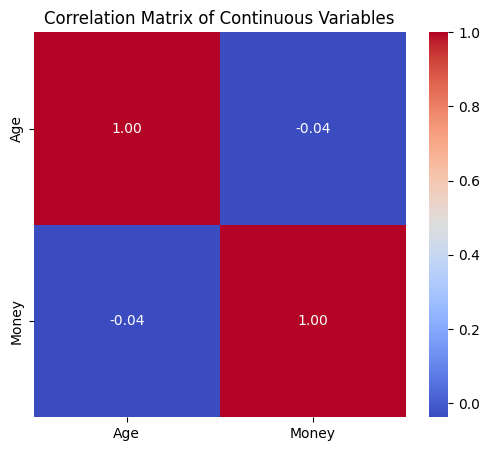


Multivariate Analysis (Pairplot for continuous variables):


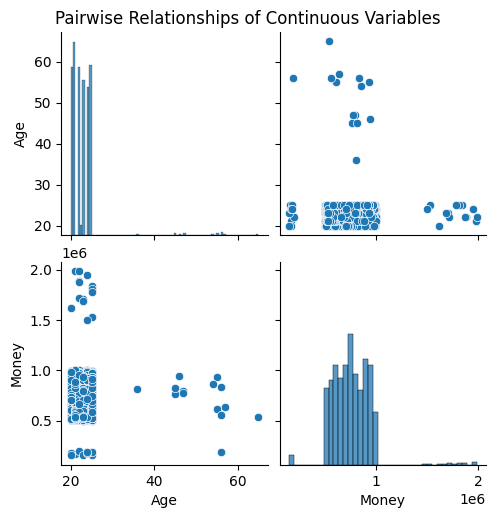


Further multivariate analysis could involve techniques like Principal Component Analysis (PCA), Multiple Regression, or Clustering, depending on specific research questions.


In [11]:
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

df_impute = df.copy()

continuous_cols = ['Age', 'Money']

print(f"--- Continuous columns identified for imputation: {continuous_cols} ---\n")

print("Missing values before imputation:")
print(df_impute[continuous_cols].isnull().sum())
print("-" * 50)


df_mean_imputed = df_impute.copy()
for col in continuous_cols:
    df_mean_imputed[col] = df_mean_imputed[col].fillna(df_mean_imputed[col].mean())
print("\nMissing values after Mean Imputation:")
print(df_mean_imputed[continuous_cols].isnull().sum())
print("-" * 50)

df_median_imputed = df_impute.copy()
for col in continuous_cols:
    df_median_imputed[col] = df_median_imputed[col].fillna(df_median_imputed[col].median())
print("\nMissing values after Median Imputation:")
print(df_median_imputed[continuous_cols].isnull().sum())
print("-" * 50)

df_ffill_imputed = df_impute.copy()
for col in continuous_cols:
    df_ffill_imputed[col] = df_ffill_imputed[col].ffill()
print("\nMissing values after Forward Fill Imputation:")
print(df_ffill_imputed[continuous_cols].isnull().sum())
print("-" * 50)

df_bfill_imputed = df_impute.copy()
for col in continuous_cols:
    df_bfill_imputed[col] = df_bfill_imputed[col].bfill()
print("\nMissing values after Backward Fill Imputation:")
print(df_bfill_imputed[continuous_cols].isnull().sum())
print("-" * 50)

df_knn_impute_data = df_impute[continuous_cols].copy()

imputer = KNNImputer(n_neighbors=5)
df_knn_imputed_array = imputer.fit_transform(df_knn_impute_data)
df_knn_imputed = pd.DataFrame(df_knn_imputed_array, columns=continuous_cols, index=df_impute.index)
print("\nMissing values after KNN Imputation:")
print(df_knn_imputed[continuous_cols].isnull().sum())
print("-" * 50)

print("\n--- Performing Analysis on Mean-Imputed Data ---")
df_analysis = df_mean_imputed.copy()

print("\nUnivariate Analysis (Descriptive Statistics for continuous variables):")
print(df_analysis[continuous_cols].describe())

plt.figure(figsize=(12, 5))
for i, col in enumerate(continuous_cols):
    plt.subplot(1, len(continuous_cols), i + 1)
    sns.histplot(df_analysis[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("\nBivariate Analysis (Correlation Matrix for continuous variables):")
correlation_matrix = df_analysis[continuous_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()
print("\nMultivariate Analysis (Pairplot for continuous variables):")
sns.pairplot(df_analysis[continuous_cols])
plt.suptitle('Pairwise Relationships of Continuous Variables', y=1.02)
plt.show()

print("\nFurther multivariate analysis could involve techniques like Principal Component Analysis (PCA), Multiple Regression, or Clustering, depending on specific research questions.")

Assignment 2